## Decision Intelligence Engine: Optimization, Simulation, & Strategy

### Objective:

**Maximize Revenue and Profitability under Uncertainty.**

This final layer transforms predictive insights into actionable business strategies by incorporating uncertainty, scenario analysis, and optimization—bridging the gap between data science and real-world decision-making.

In [ ]:
# Data Prep

import pandas as pd
import numpy as np

df = pd.read_csv('df_final.csv')
ts = pd.read_csv('ts_data.csv')

# Feature Engineering: Base Metrics

gp = df.groupby('InvoiceDate')['GrossProfit'].sum().reset_index() # Will use this in the Simulation as the "Profit" Value

base_rev = ts['Revenue'].mean()
base_profit = gp['GrossProfit'].max()

# Proxy Measures for the Upcoming Simulation

retention_rate = 0.6 # Proxy
cac = 50 # Proxy (Customer Acquisition Cost)

In [ ]:
def sim_business(rev, profit, retention_change = 0, cac_change = 0): # Simulation (What-if Analysis)
  new_rev = (rev * (1 + retention_change)) - (cac * (1 + cac_change)) # New Revenue
  new_rev_change = ((new_rev - rev)/ rev) * 100 # % Change in Revenue

  new_profit = (profit * (1 + retention_change)) - (cac * (1 + cac_change)) # New Profit
  new_profit_change = ((new_profit - profit)/ profit) * 100 # % Change in Profit

  return new_rev, new_profit, new_rev_change, new_profit_change

In [ ]:
# You may Simulate with your Metrics as needed

sim_new_rev, sim_new_profit, sim_new_rev_change, sim_new_profit_change = sim_business(
    base_rev,
    base_profit,
    retention_change = 0.1, # There are in % Form
    cac_change = -0.05)

results = pd.DataFrame({
    'Metric': ['Base Revenue', 'Simulated New Revenue', 'Simulated Revenue Change',
               'Base Profit', 'Simulated New Profit', 'Simulated Profit Change'],
    'Value': [base_rev, sim_new_rev, sim_new_rev_change,
              base_profit, sim_new_profit, sim_new_profit_change]
})

display(results.round(2)) # Wow, that is a huge Increase in both Health Metrics!

,Metric,Value
0,Base Revenue,13991.59
1,Simulated New Revenue,15343.24
2,Simulated Revenue Change,9.66
3,Base Profit,33228.78
4,Simulated New Profit,36504.16
5,Simulated Profit Change,9.86




---

## BONUS: Try it Yourself!

In [ ]:
# Put in your own Business's Metrics & Plan Ahead

# Enter each in % Form, please - e.g., 0.1 for +10%

ret = float(input("Enter Retention Change: "))
cac_change = float(input("Enter CAC Change: "))

# Prepare & Store all Four Returned Values from "sim_business"

new_rev, new_profit, new_rev_change, new_profit_change = sim_business(
    base_rev,
    base_profit,
    ret,
    cac_change)

# View your Results!

print(f"New Revenue: {new_rev:.2f} (Change: {new_rev_change:.2f}%) ")
print(f"New Profit: {new_profit:.2f} (Change: {new_profit_change:.2f}%) ")



---

## Monte Carlo Simulation

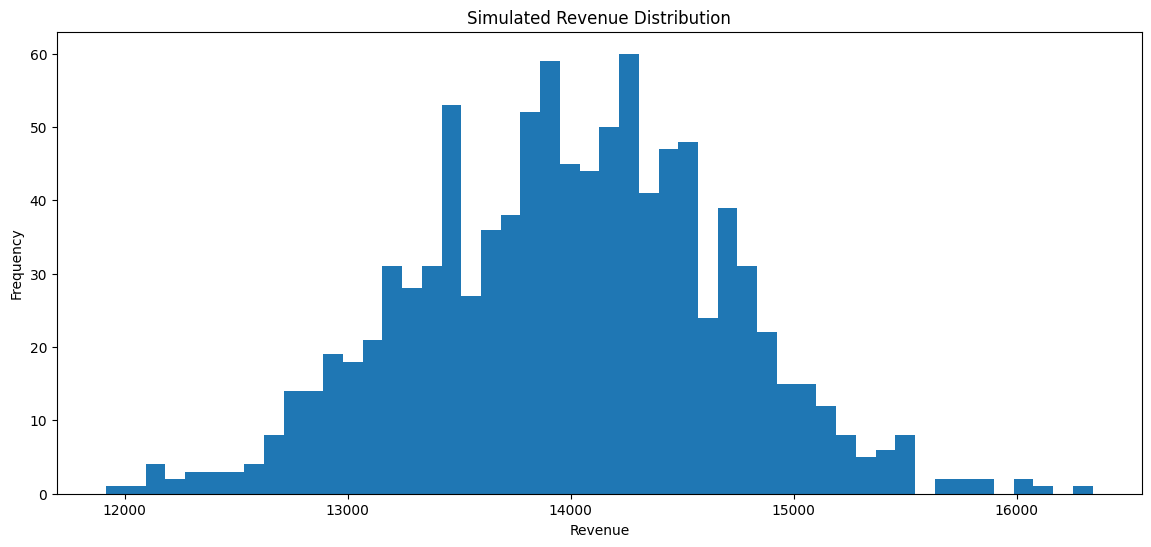

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

sim_results = []

for _ in range(1000):
    demand_shock = np.random.normal(0, 0.05)
    sim_rev = base_rev * (1 + demand_shock)
    sim_results.append(sim_rev)

# Visualized Monte Carlo Simulation

plt.figure(figsize = (14, 6))
plt.hist(sim_results, bins = 50)
plt.title("Simulated Revenue Distribution")
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

“Revenue outcomes show variability, indicating planning uncertainty. Businesses should prepare for both upside opportunities and downside risks.”



---

## The Big Dog: **Bayesian Optimization**

This is more about *where to look next*, instead of trying every combination.

Let's find the best Decision settings (like Retention vs CAC) and efficiently so.

In [ ]:
!pip install optuna

In [ ]:
import optuna

In [ ]:
# The Objective Function

def objective(trial):
  # Parameters to Optimize
  retention = trial.suggest_float("retention", 0.5, 0.9)
  cac = trial.suggest_float("cac", 20, 100)

  # Simulated Revenue Logic
  revenue = base_rev * (1 + (retention - 0.6))
  profit = revenue - cac

  return profit

In [ ]:
# Run the Optimization!

study = optuna.create_study(direction = 'maximize')
study.optimize(objective, n_trials = 50)

[I 2026-05-06 18:46:45,869] A new study created in memory with name: no-name-770bbdba-dee9-4ddd-9d9a-bc82113c999d
[I 2026-05-06 18:46:45,873] Trial 0 finished with value: 14853.674375803455 and parameters: {'retention': 0.6674460583980372, 'cac': 81.58895063370832}. Best is trial 0 with value: 14853.674375803455.
[I 2026-05-06 18:46:45,875] Trial 1 finished with value: 17464.15132423241 and parameters: {'retention': 0.8519750076407884, 'cac': 52.96466502433888}. Best is trial 1 with value: 17464.15132423241.
[I 2026-05-06 18:46:45,877] Trial 2 finished with value: 13069.588769028758 and parameters: {'retention': 0.5371736594839915, 'cac': 42.95708457622905}. Best is trial 1 with value: 17464.15132423241.
[I 2026-05-06 18:46:45,879] Trial 3 finished with value: 13443.654020874726 and parameters: {'retention': 0.5663061303677468, 'cac': 76.50130449281767}. Best is trial 1 with value: 17464.15132423241.
[I 2026-05-06 18:46:45,880] Trial 4 finished with value: 15455.16789821575 and paramet

In [ ]:
# Visualized: The Bayesian Optimization Plot

optuna.visualization.plot_optimization_history(study)

In [ ]:
# The Results

print("Best Parameters:", study.best_params)
print("Best Profit:", study.best_value)

Best Parameters: {'retention': 0.8989226103709499, 'cac': 21.57480432787175}
Best Profit: 18152.412606021768


**Interpretation:**

Bayesian Optimization identified optimal combinations of retention and acquisition cost that maximize profitability, demonstrating how data-driven tuning of business levers can significantly impact financial outcomes.

Summary:

Optimization results indicate that increasing customer retention yields significantly higher returns than minimizing acquisition costs. The business should prioritize retention-focused strategies, even if it involves moderately higher CAC, as long as customer lifetime value remains strong.

The business should look into:

* Investing in loyalty programs and personalized engagement strategies.
* Realize that, very likely, a small increase in Retention leads to a larger increase in Profit compared to a similar increase in CAC leading to a smaller decrease in Profit.

Key Takeaways:

* Profitability is maximized when *customer retention is aggressively optimized*, even at moderately higher acquisition costs. In other words, **Retention is the Primary Driver**.
* Model pushes Retention to the Upper Bound (~90%), indicating that Retention has a stronger **Marginal impact** on Profit than CAC Reduction.
* CAC is decently affordable and quite acceptable to a certain point - the **Optimal CAC is ~$22**. In other words, spending to acquire valuable, retainable customers is very much justified.